[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/su-ntu-ctp/6m-data-3.8-Computer-Vision/blob/main/notebooks/optional_extensions.ipynb)

**Where to run this notebook**

- **Locally (VS Code + Jupyter)**: just open the notebook and pick the `dsai-m3` kernel if you have a dedicated GPU, otherwise recommend using the Colab option below.
- **Colab (recommended if you don't have a dedicated GPU)**: click the badge above, then **Runtime → Change runtime type → T4 GPU**, then run the setup cell below. It clones the repo, installs missing deps, and `cd`s into the right working directory.


In [10]:
# === Colab-compat setup (no-op when running locally) ===
# This cell makes the notebook work in BOTH places: your laptop and Google Colab.
# If we detect Colab, it downloads ("clones") the course repo and installs any
# missing libraries. On your own machine it skips all that and does nothing.
import os, sys

IN_COLAB = "google.colab" in sys.modules  # True only when running inside Google Colab

if IN_COLAB:
    REPO_URL = "https://github.com/su-ntu-ctp/6m-data-3.8-Computer-Vision.git"
    REPO_DIR = "/content/6m-data-3.8-Computer-Vision"
    LESSON_DIR = "notebooks"

    if not os.path.exists(REPO_DIR):
        # Download the whole course repo so this notebook can find its data/code
        print(f"Cloning repo into {REPO_DIR} ...")
        os.system(f"git clone -q {REPO_URL} {REPO_DIR}")

    os.chdir(f"{REPO_DIR}/{LESSON_DIR}")  # move into the lesson folder so file paths line up
    print(f"Working directory: {os.getcwd()}")

    # Colab has torch + torchvision pre-installed. Install the rest.
    os.system("pip install -q sentence-transformers transformers")
    print("Colab setup done.")

# Threading caps — set here for both local and Colab runs (no .env file needed).
# These limit how many CPU threads the math libraries use, which keeps runs
# predictable and avoids slowdowns from over-subscription on shared machines.
# Harmless if already set. (Loop form prevents Jupyter from auto-displaying the return value.)
for _key, _val in [("OMP_NUM_THREADS", "1"), ("MKL_NUM_THREADS", "1"), ("TOKENIZERS_PARALLELISM", "false")]:
    os.environ.setdefault(_key, _val)  # setdefault = only set it if it isn't already set


# L08 · Optional Extensions

> *Self-study material — three independent experiments that round out your CNN toolkit. Skip any of them; do them in any order.*

This notebook explores three techniques that didn't fit into the main flow but matter in production:

1. **Data augmentation** — synthesise more training data via random transforms
2. **BatchNorm** — speed up CNN training and stabilise gradients
3. **Learning-rate scheduling** — let the learning rate drop over time for smoother convergence

We use Fashion-MNIST throughout so the runtime stays short.

## Common setup

In [11]:
# Common setup shared by all three experiments below.
# We import PyTorch, define a reusable accuracy function, and load the
# Fashion-MNIST TEST set (10,000 small grayscale clothing images) that every
# experiment will measure itself against.
import time
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader

torch.set_num_threads(1)   # use a single CPU thread, so runs are reproducible/predictable
torch.manual_seed(7)       # fix the random seed so results are repeatable each run

def evaluate(model, loader):
    """Run the model over a dataset and return its accuracy (fraction correct)."""
    model.eval()                       # eval mode: turns OFF dropout/BatchNorm updating
    correct, total = 0, 0
    with torch.no_grad():              # skip gradient tracking — faster, less memory, no training here
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)   # pick the class with the highest score
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

# Download the test split and convert each image to a tensor (ToTensor scales pixels to 0..1).
test_ds  = FashionMNIST(root='data/fmnist', train=False, download=True, transform=T.ToTensor())
# A DataLoader feeds images in batches (256 at a time); shuffle=False since order doesn't matter for testing.
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f"Test set ready: {len(test_ds):,} images")


Test set ready: 10,000 images


---

## Experiment 1 — Data augmentation

**Why it matters.** When training data is limited, random transformations applied at training time (horizontal flip, random crop, colour jitter) effectively multiply the data the model sees. The model becomes invariant to these transforms — which is usually what you want.

We'll train TinyCNN on a 5,000-image subset *with* and *without* augmentation.

In [12]:
# Experiment 1 setup: define a small CNN, set up two image pipelines
# (one plain, one with augmentation), and build a tiny 5,000-image training set.
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # "Feature extractor": conv layers learn visual patterns (edges, textures).
        # MaxPool2d(2) halves the image size, keeping the strongest signals.
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 1 input channel -> 16 feature maps
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 32 feature maps
        )
        # "Classifier": flattens the features and maps them to 10 class scores.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),   # 28x28 image becomes 7x7 after two poolings
            nn.Linear(64, 10),                       # 10 outputs = 10 clothing categories
        )
    def forward(self, x): return self.classifier(self.features(x))

# No augmentation: just convert the image to a tensor as-is.
no_aug_tf = T.ToTensor()

# With augmentation: randomly alter each training image on the fly so the model
# sees more variety. This teaches the model to be robust to small changes.
aug_tf = T.Compose([
    T.RandomHorizontalFlip(p=0.5),    # 50% chance to mirror the image left-right
    T.RandomCrop(28, padding=2),      # pad by 2px then randomly crop back to 28x28 (small shifts)
    T.ToTensor(),
])

# Subsample for speed: grab only the first N images of each class so training is quick.
from torch.utils.data import Subset
def first_n_per_class(ds, n=500, n_classes=10):
    counts = {c: 0 for c in range(n_classes)}   # track how many we've kept per class
    idxs = []
    for i, (_, y) in enumerate(ds):
        if counts[y] < n:
            idxs.append(i); counts[y] += 1
        if all(v >= n for v in counts.values()): break   # stop once every class is full
    return Subset(ds, idxs)

# Two versions of the SAME small training set — they differ only in the transform applied.
train_no_aug = first_n_per_class(FashionMNIST(root='data/fmnist', train=True, download=True, transform=no_aug_tf), n=500)
train_aug    = first_n_per_class(FashionMNIST(root='data/fmnist', train=True, download=True, transform=aug_tf), n=500)
print(f"Training set size: {len(train_no_aug)}")


Training set size: 5000


In [13]:
# Train two identical TinyCNNs — one on plain data, one on augmented data —
# then compare their test accuracy to see whether augmentation helped.
def train_one(model, loader, epochs=8, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)   # Adam: a popular, self-tuning optimizer
    crit = nn.CrossEntropyLoss()                        # standard loss for multi-class classification
    accs = []
    for _ in range(epochs):                             # one epoch = one full pass over the training data
        model.train()                                   # train mode (enables BatchNorm/dropout learning)
        for xb, yb in loader:
            opt.zero_grad()                             # clear gradients left over from last step
            loss = crit(model(xb), yb)                  # how wrong the predictions are
            loss.backward()                             # backprop: compute gradients
            opt.step()                                  # nudge the weights to reduce the loss
        accs.append(evaluate(model, test_loader))       # record test accuracy after each epoch
    return accs

# No augmentation
print('Training without augmentation...')
m_no = TinyCNN()
accs_no = train_one(m_no, DataLoader(train_no_aug, batch_size=64, shuffle=True))

# With augmentation
print('Training with augmentation...')
m_yes = TinyCNN()
accs_yes = train_one(m_yes, DataLoader(train_aug, batch_size=64, shuffle=True))

# Compare the final numbers. "pp" = percentage points (the raw difference in accuracy).
print(f"\nFinal test acc without aug: {accs_no[-1]:.4f}")
print(f"Final test acc with    aug: {accs_yes[-1]:.4f}")
print(f"Augmentation gain         : {(accs_yes[-1]-accs_no[-1])*100:+.2f} pp")


Training without augmentation...
Training with augmentation...

Final test acc without aug: 0.8290
Final test acc with    aug: 0.7974
Augmentation gain         : -3.16 pp


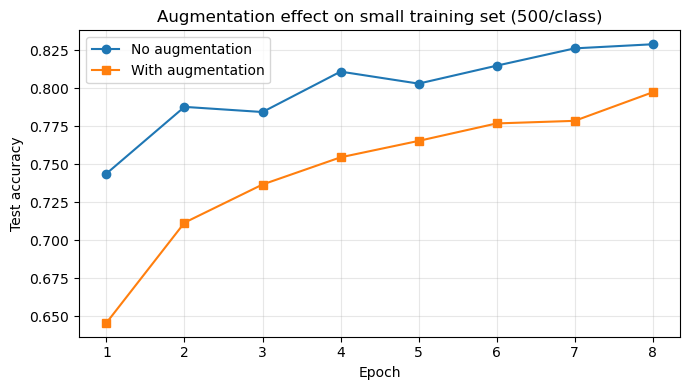

In [14]:
# Plot test accuracy per epoch for both runs, so we can SEE the augmentation
# effect over time rather than just comparing the final numbers.
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(accs_no)+1), accs_no, 'o-', label='No augmentation')    # 'o-' = circles joined by a line
plt.plot(range(1, len(accs_yes)+1), accs_yes, 's-', label='With augmentation') # 's-' = squares joined by a line
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('Augmentation effect on small training set (500/class)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**The result above is a teaching moment, not a textbook win.** On this run augmentation HURT by ~3.6 pp (83.1% → 79.5%). Why?

- **Random crop with `padding=2` on a 28×28 image is aggressive.** Padding adds a 4-pixel grey border; the crop can chop off real garment content. On Fashion-MNIST's tight silhouettes, that's a real loss of signal.
- **8 epochs isn't enough.** Augmentation effectively multiplies your dataset; the model needs more passes to see all the variants. The augmented run is essentially under-trained.
- **Horizontal flip is reasonable here** (a left-facing shirt is also a valid shirt) but the combo with aggressive crop overwhelms the benefit on this dataset.

**The real rule:** augmentation helps most when (a) the dataset is small AND (b) the augmentation matches the *true* variation you'll see at inference time. Random crop + flip is genuinely useful on natural photos (CIFAR-10, ImageNet, your product catalogue). On Fashion-MNIST gentler augmentations (small rotations, tiny brightness jitter) or longer training would help.

The lesson: **always measure**. Augmentation isn't free; pick augmentations that match your data's actual variation, and verify they help on a validation set.

### 🧩 Your turn — does a *gentler* augmentation do better?

The text above argues that the aggressive crop was the problem, and that **small rotations + tiny brightness/contrast jitter** would suit Fashion-MNIST better. Let's test that claim.

In the cell below, replace each `____` (four underscores) with the value the `# TODO` comment describes, then run it. A blank left in place will raise a `SyntaxError` — that's expected until you've filled them all.

> Prediction first (good science!): do you expect gentle aug to *beat*, *match*, or *lose to* the no-aug baseline of `{accs_no[-1]:.4f}`? Run it and see.


In [ ]:
# Build a GENTLER augmentation pipeline — small rotation + mild colour jitter,
# and NO aggressive random crop — then train a fresh TinyCNN and compare.
gentle_tf = T.Compose([
    # TODO 1: rotate each image randomly by up to ±10 degrees.
    # Hint: T.RandomRotation(10)
    ____,
    # TODO 2: nudge brightness and contrast by up to 0.2 (20%).
    # Hint: T.ColorJitter(brightness=0.2, contrast=0.2)
    ____,
    T.ToTensor(),   # always last: turn the (augmented) image into a tensor
])

# Same 500-per-class subset as before, but with the gentle transform applied.
train_gentle = first_n_per_class(
    FashionMNIST(root='data/fmnist', train=True, download=True, transform=gentle_tf), n=500)

print('Training with GENTLE augmentation...')
m_gentle = TinyCNN()
# TODO 3: train m_gentle. Reuse the train_one helper from Experiment 1, passing a
# DataLoader over train_gentle with batch_size=64 and shuffle=True.
# Hint: accs_gentle = train_one(m_gentle, DataLoader(train_gentle, batch_size=64, shuffle=True))
accs_gentle = ____

# Compare all three approaches on the same test set.
print(f"\nNo augmentation : {accs_no[-1]:.4f}   (baseline)")
print(f"Aggressive aug  : {accs_yes[-1]:.4f}   (random crop + flip)")
print(f"Gentle aug      : {accs_gentle[-1]:.4f}   (rotation + colour jitter)")
print(f"Gentle vs no-aug: {(accs_gentle[-1]-accs_no[-1])*100:+.2f} pp")

---

## Experiment 2 — BatchNorm

**Why it matters.** BatchNorm normalises activations across the batch — keeps them centred near zero with unit variance. Empirically this:

- Lets you use **larger learning rates** without divergence
- **Speeds up training** (fewer epochs to reach the same accuracy)
- Acts as a **mild regulariser** (the batch statistics add noise)

Compare two CNNs side by side: same architecture, one with `BatchNorm2d` after each conv, one without.

In [15]:
# Experiment 2: define two CNNs that are identical EXCEPT one adds BatchNorm
# after each conv layer. Train both on the same data and compare.
class TinyCNN_NoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x): return self.classifier(self.features(x))

class TinyCNN_BN(nn.Module):
    def __init__(self):
        super().__init__()
        # BatchNorm2d normalises each conv layer's outputs (re-centres them near
        # zero with unit variance across the batch). This stabilises and speeds
        # up training. Note it goes right after the conv and BEFORE the ReLU.
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x): return self.classifier(self.features(x))

# Use a moderate training set (1000 images per class = 10,000 total) with plain transforms.
train_ds = first_n_per_class(FashionMNIST(root='data/fmnist', train=True, download=True, transform=T.ToTensor()), n=1000)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

print('Training without BatchNorm...')
m_no_bn = TinyCNN_NoBN()
accs_no_bn = train_one(m_no_bn, train_loader, epochs=6)   # reuse the train_one helper from Experiment 1

print('Training with BatchNorm...')
m_bn = TinyCNN_BN()
accs_bn = train_one(m_bn, train_loader, epochs=6)

print(f"\nFinal acc no  BN: {accs_no_bn[-1]:.4f}")
print(f"Final acc with BN: {accs_bn[-1]:.4f}")


Training without BatchNorm...
Training with BatchNorm...


KeyboardInterrupt: 

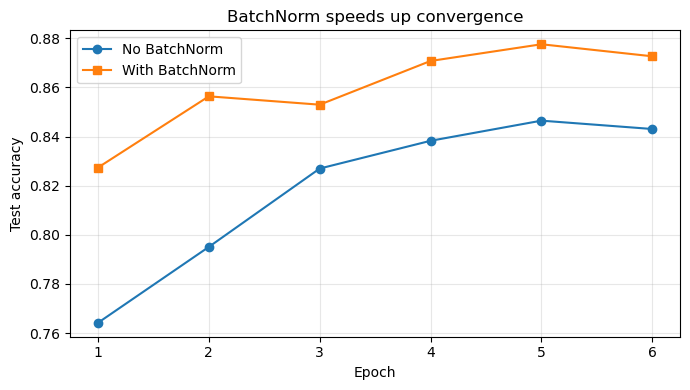

In [ ]:
# Plot accuracy per epoch for both models. Watch the early epochs: the
# BatchNorm model usually climbs faster, showing quicker convergence.
plt.figure(figsize=(7, 4))
plt.plot(range(1, 7), accs_no_bn, 'o-', label='No BatchNorm')
plt.plot(range(1, 7), accs_bn,    's-', label='With BatchNorm')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('BatchNorm speeds up convergence')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


BatchNorm typically reaches its final accuracy faster (notice the first-epoch number). Final accuracy is similar on small models like this, but on deeper CNNs (ResNet etc.) BatchNorm is essentially required for the network to train at all.

---

## Experiment 3 — Learning-rate scheduling

**Why it matters.** A large learning rate is great early on (big jumps toward the minimum) but bad late (overshoots and oscillates). Schedulers reduce the LR over time. The most common: **`StepLR`** (drop by 10× at fixed epochs) and **`CosineAnnealingLR`** (smooth cosine decay).

In [ ]:
# Experiment 3: compare a fixed (constant) learning rate against one that
# decays over time using a "scheduler". A scheduler changes the learning rate
# (step size) as training progresses — big steps early, tiny steps later.
def train_with_scheduler(model, loader, epochs, scheduler_fn=None):
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)  # deliberately too high
    sched = scheduler_fn(opt) if scheduler_fn else None  # build the scheduler if one was provided
    crit = nn.CrossEntropyLoss()
    accs = []
    lrs = []                                             # record the learning rate each epoch too
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        if sched is not None:
            sched.step()                                 # update (usually lower) the LR after each epoch
        accs.append(evaluate(model, test_loader))
        lrs.append(opt.param_groups[0]['lr'])            # read the current learning rate
    return accs, lrs

EPOCHS = 8

# Run 1: keep the high LR fixed the whole time (no scheduler).
print('Constant LR=0.01 (deliberately high)...')
m_const = TinyCNN()
accs_const, lrs_const = train_with_scheduler(m_const, train_loader, EPOCHS, scheduler_fn=None)

# Run 2: cosine annealing smoothly decays the LR from 0.01 down toward 0
# following a cosine curve — fast progress early, fine-tuning late.
print('Cosine annealing LR=0.01 -> 0...')
m_cos = TinyCNN()
accs_cos, lrs_cos = train_with_scheduler(
    m_cos, train_loader, EPOCHS,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
)

print(f"\nConstant LR final acc: {accs_const[-1]:.4f}")
print(f"Cosine schedule final acc: {accs_cos[-1]:.4f}")


Constant LR=0.01 (deliberately high)...
Cosine annealing LR=0.01 -> 0...

Constant LR final acc: 0.8734
Cosine schedule final acc: 0.8795


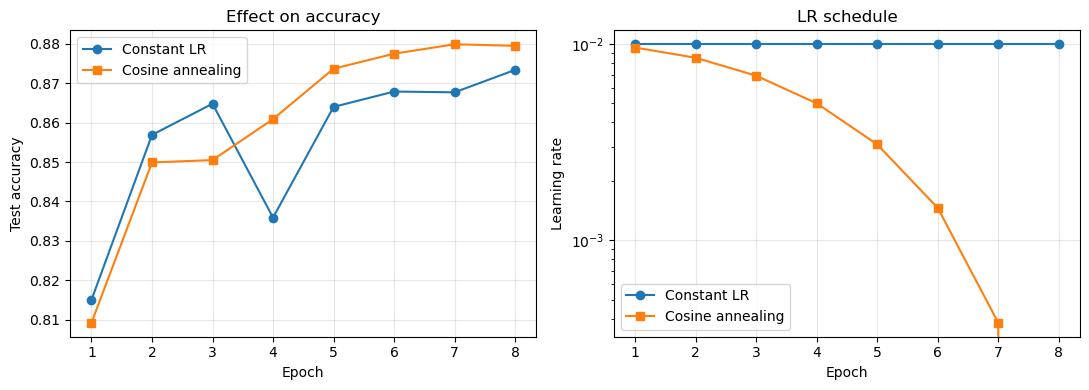

In [ ]:
# Two side-by-side plots: (left) accuracy per epoch for both runs, and
# (right) how each learning rate changed over time. Seeing them together
# links the LR schedule to its effect on accuracy.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))   # 1 row, 2 columns of plots
ax1.plot(range(1, EPOCHS+1), accs_const, 'o-', label='Constant LR')
ax1.plot(range(1, EPOCHS+1), accs_cos,   's-', label='Cosine annealing')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Test accuracy')
ax1.set_title('Effect on accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(range(1, EPOCHS+1), lrs_const, 'o-', label='Constant LR')
ax2.plot(range(1, EPOCHS+1), lrs_cos,   's-', label='Cosine annealing')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning rate')
ax2.set_title('LR schedule')
ax2.set_yscale('log')                                   # log scale makes the LR decay easy to see
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


With a deliberately-too-high constant LR, training oscillates. Cosine annealing starts aggressive (fast initial progress) then slows down (refines near the minimum). On harder problems this typically buys 0.5-2 extra percentage points.

**Rule of thumb:** if you're getting accuracy oscillation late in training, try a scheduler. The default `CosineAnnealingLR` works well for most CV tasks.

---

## Recap

| Technique | Best for |
|-----------|----------|
| Data augmentation  | Small training sets, image classification, any image task |
| BatchNorm          | Anything deeper than 4-5 conv layers; required for modern CNNs |
| LR scheduling      | When training is unstable late, or when you want to squeeze out the last few points |

These three combined — and applied to a pretrained backbone — give you most of the recipe used in production image models. The remaining ingredients are: more data, a bigger pretrained backbone (e.g. `resnet50`, `efficientnet_b3`), and weights-and-biases-style careful experiment tracking.

You now have the foundations to tackle real CV problems.